# Analysis of Vegetable Prices and Diesel Prices in Sri Lanka (2018-2019)

This notebook explores the relationship between vegetable prices and diesel prices in Sri Lanka for the years 2018 and 2019. Using data from major markets (Meegoda, Colombo, Kandy, Dambulla), it performs the following analyses:

- **Data Preparation:** Filtering and cleaning of the dataset for selected vegetables and time period.
- **Visualization:** Dual-axis line charts and scatter plots to visualize trends and relationships between vegetable prices and diesel prices.
- **Statistical Analysis:** Calculation of Pearson and Spearman correlation coefficients, as well as mutual information scores, to quantify the strength of relationships.
- **Correlation Heatmap:** Weekly mean prices are pivoted and correlated with economic features (diesel price, USD exchange rate).
- **Interpretation:** Each step includes visual and statistical interpretation to help understand the impact of diesel price changes on vegetable prices.

The notebook is structured for reproducibility and clarity, making it useful for researchers, policymakers, and anyone interested in agricultural economics in Sri Lanka.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Set seaborn style
sns.set(style='whitegrid')
# Color palette for vegetables
veg_colors = {
    'CARROT': 'orange',
    'PUMPKIN': 'green',
    'BRINJALS': 'purple',
    'BEETROOT': 'red'
}

## Step 1 — Data Preparation
- Filter to Meegoda and selected vegetables
- Filter for 2018-2019
- Create time_index
- Sort and drop null prices

In [2]:
# Load data
df = pd.read_csv('../main data set/main_data_cleaned.csv')

# Filter for 2018-2019
df = df[(df['year'] >= 2018) & (df['year'] <= 2019)]

# Filter for Meegoda and selected vegetables
veg_list = ['CARROT', 'PUMPKIN', 'BRINJALS', 'BEETROOT']
df_meegoda = df[(df['location'] == 'Meegoda') & (df['vegetable_type'].isin(veg_list))].copy()

# Create time_index
df_meegoda['time_index'] = df_meegoda['year'] * 100 + df_meegoda['week_num']
# Sort
df_meegoda = df_meegoda.sort_values('time_index')
# Drop rows with null price
df_meegoda = df_meegoda.dropna(subset=['price'])
df_meegoda.reset_index(drop=True, inplace=True)
df_meegoda.head()

,Year_Week,year,location,code,vegetable_type,price,no_of_holidays,vegetable_zone,seasonality,lanka_auto_diesel_price,mean_apparent_temperature,rain_sum,usd_exchange_rate,week_num,time_index
0,2018-W01,2018,Meegoda,323,PUMPKIN,115.0,NaN,NaN,NaN,95.0,NaN,NaN,153.6000,1,201801
1,2018-W01,2018,Meegoda,303,CARROT,190.0,NaN,NaN,NaN,95.0,NaN,NaN,153.6000,1,201801
2,2018-W01,2018,Meegoda,305,BEETROOT,215.0,NaN,NaN,NaN,95.0,NaN,NaN,153.6000,1,201801
3,2018-W01,2018,Meegoda,321,BRINJALS,245.0,NaN,NaN,NaN,95.0,NaN,NaN,153.6000,1,201801
4,2018-W02,2018,Meegoda,323,PUMPKIN,116.0,NaN,NaN,NaN,95.0,NaN,NaN,153.8714,2,201802


## Step 2 — Dual-axis Line Chart (Meegoda, 4 vegetables vs diesel)
- Each subplot: vegetable price (left), diesel price (right)
- Save as plot1_dual_axis_meegoda_2018_2019.png

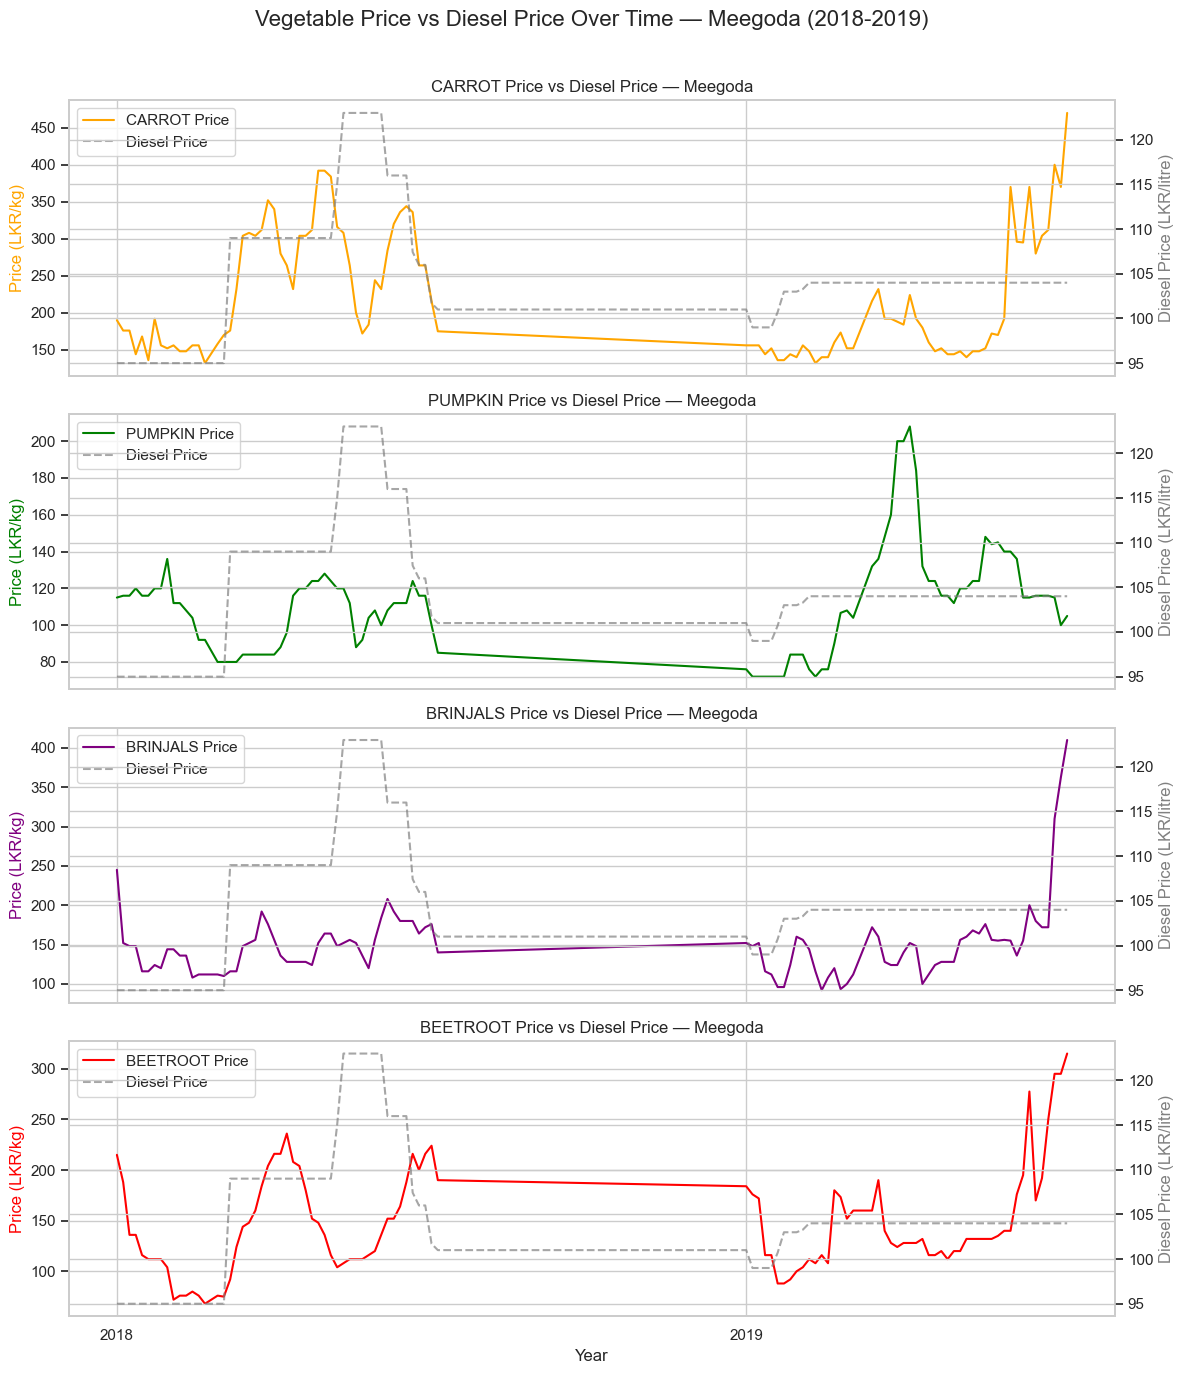

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
for i, veg in enumerate(veg_list):
    ax = axes[i]
    data = df_meegoda[df_meegoda['vegetable_type'] == veg]
    # Left y-axis: vegetable price
    l1 = ax.plot(data['time_index'], data['price'], color=veg_colors[veg], label=f'{veg} Price')
    ax.set_ylabel('Price (LKR/kg)', color=veg_colors[veg])
    # Right y-axis: diesel price
    ax2 = ax.twinx()
    l2 = ax2.plot(data['time_index'], data['lanka_auto_diesel_price'], color='grey', linestyle='--', alpha=0.7, label='Diesel Price')
    ax2.set_ylabel('Diesel Price (LKR/litre)', color='grey')
    # Title
    ax.set_title(f'{veg} Price vs Diesel Price — Meegoda')
    # Legend
    lines = l1 + l2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper left')
    # X-ticks: first week of each year
    years = sorted(data['year'].unique())
    xticks = [y * 100 + 1 for y in years]
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(y) for y in years])
    if i < 3:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Year')
plt.suptitle('Vegetable Price vs Diesel Price Over Time — Meegoda (2018-2019)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('plot1_dual_axis_meegoda_2018_2019.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3 — Scatter Plot (diesel vs price, all 4 vegetables)
- Color by vegetable, regression line, Pearson r
- Save as plot2_scatter_meegoda_2018_2019.png

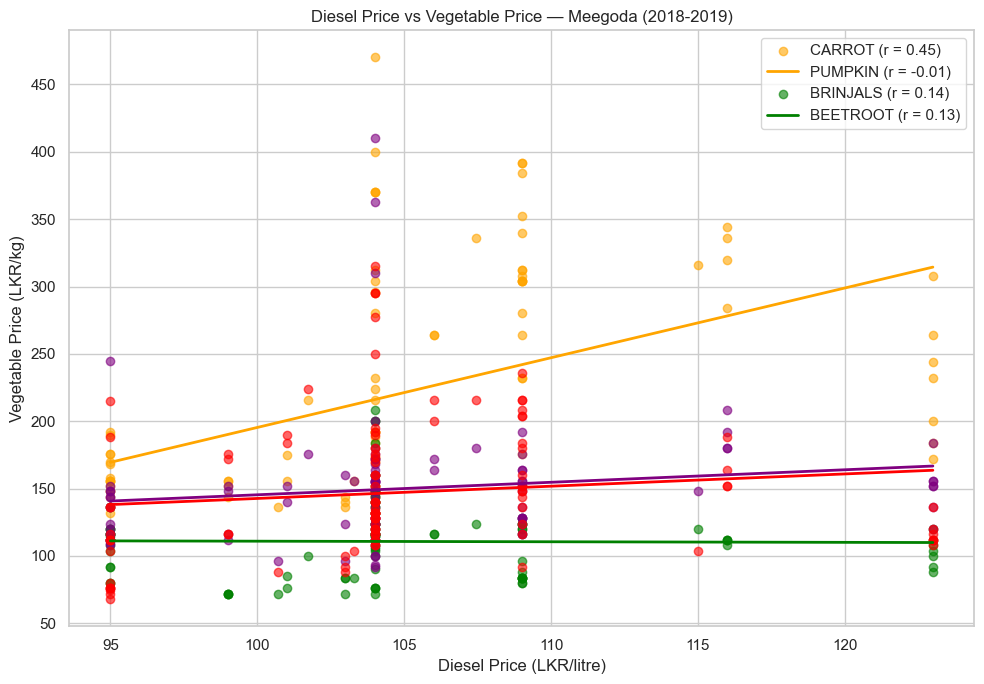

In [4]:
plt.figure(figsize=(10, 7))
legend_labels = []
for veg in veg_list:
    data = df_meegoda[df_meegoda['vegetable_type'] == veg]
    plt.scatter(data['lanka_auto_diesel_price'], data['price'], color=veg_colors[veg], alpha=0.6, label=veg)
    # Regression line
    if len(data) > 1:
        coef = np.polyfit(data['lanka_auto_diesel_price'], data['price'], 1)
        xfit = np.linspace(data['lanka_auto_diesel_price'].min(), data['lanka_auto_diesel_price'].max(), 100)
        yfit = coef[0] * xfit + coef[1]
        plt.plot(xfit, yfit, color=veg_colors[veg], linewidth=2)
        # Pearson r
        r, _ = pearsonr(data['lanka_auto_diesel_price'], data['price'])
        legend_labels.append(f'{veg} (r = {r:.2f})')
    else:
        legend_labels.append(f'{veg} (r = N/A)')
plt.xlabel('Diesel Price (LKR/litre)')
plt.ylabel('Vegetable Price (LKR/kg)')
plt.title('Diesel Price vs Vegetable Price — Meegoda (2018-2019)')
plt.legend(legend_labels)
plt.tight_layout()
plt.savefig('plot2_scatter_meegoda_2018_2019.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Correlation Heatmap (Meegoda, all vegetables)
- Pivot to weekly mean price per vegetable
- Add diesel and USD columns
- Pearson correlation matrix
- Save as plot3_correlation_heatmap_meegoda_2018_2019.png

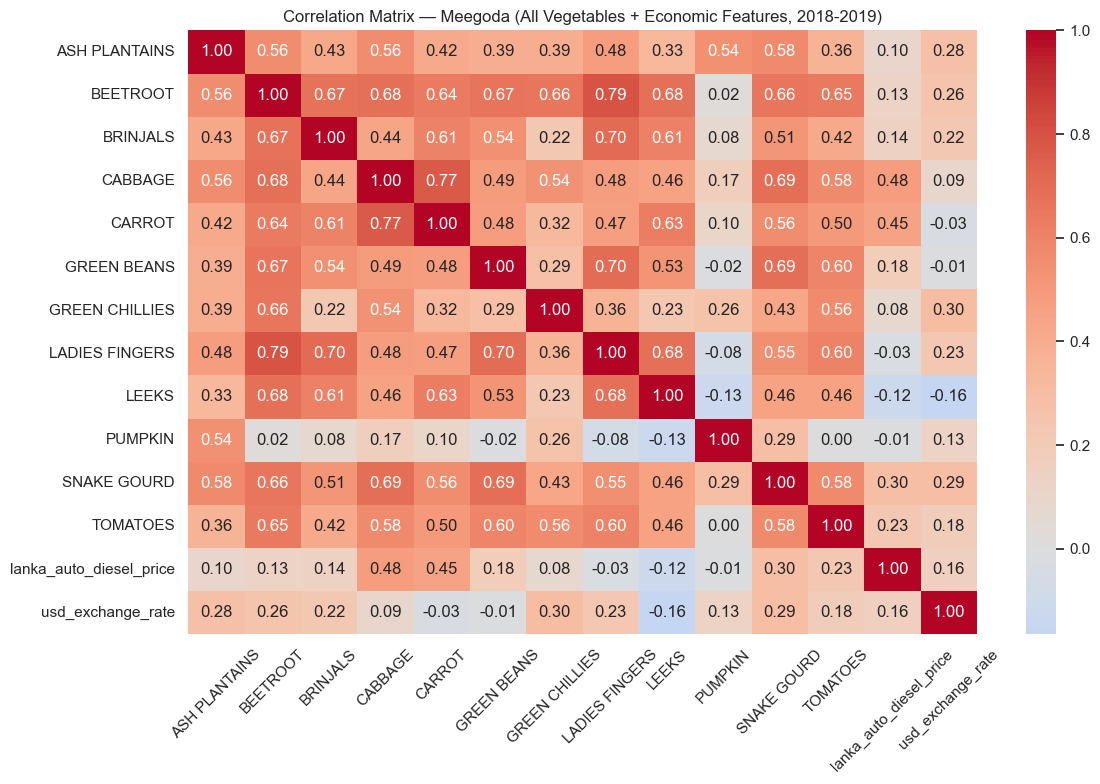

In [5]:
# Filter to Meegoda, all vegetables
df_meegoda_all = df[df['location'] == 'Meegoda'].copy()
df_meegoda_all['time_index'] = df_meegoda_all['year'] * 100 + df_meegoda_all['week_num']
# Pivot: mean price per veg per week
price_pivot = df_meegoda_all.pivot_table(index='time_index', columns='vegetable_type', values='price', aggfunc='mean')
# Add diesel and USD
diesel_usd = df_meegoda_all.groupby('time_index')[['lanka_auto_diesel_price', 'usd_exchange_rate']].mean()
corr_df = price_pivot.join(diesel_usd)
# Correlation matrix
corr = corr_df.corr(method='pearson')
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Meegoda (All Vegetables + Economic Features, 2018-2019)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot3_correlation_heatmap_meegoda_2018_2019.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Dual-axis Line Chart for Colombo, Kandy, Dambulla
- Repeat Step 2 for each location
- Save as plot4_dual_axis_colombo_2018_2019.png, plot5_dual_axis_kandy_2018_2019.png, plot6_dual_axis_dambulla_2018_2019.png

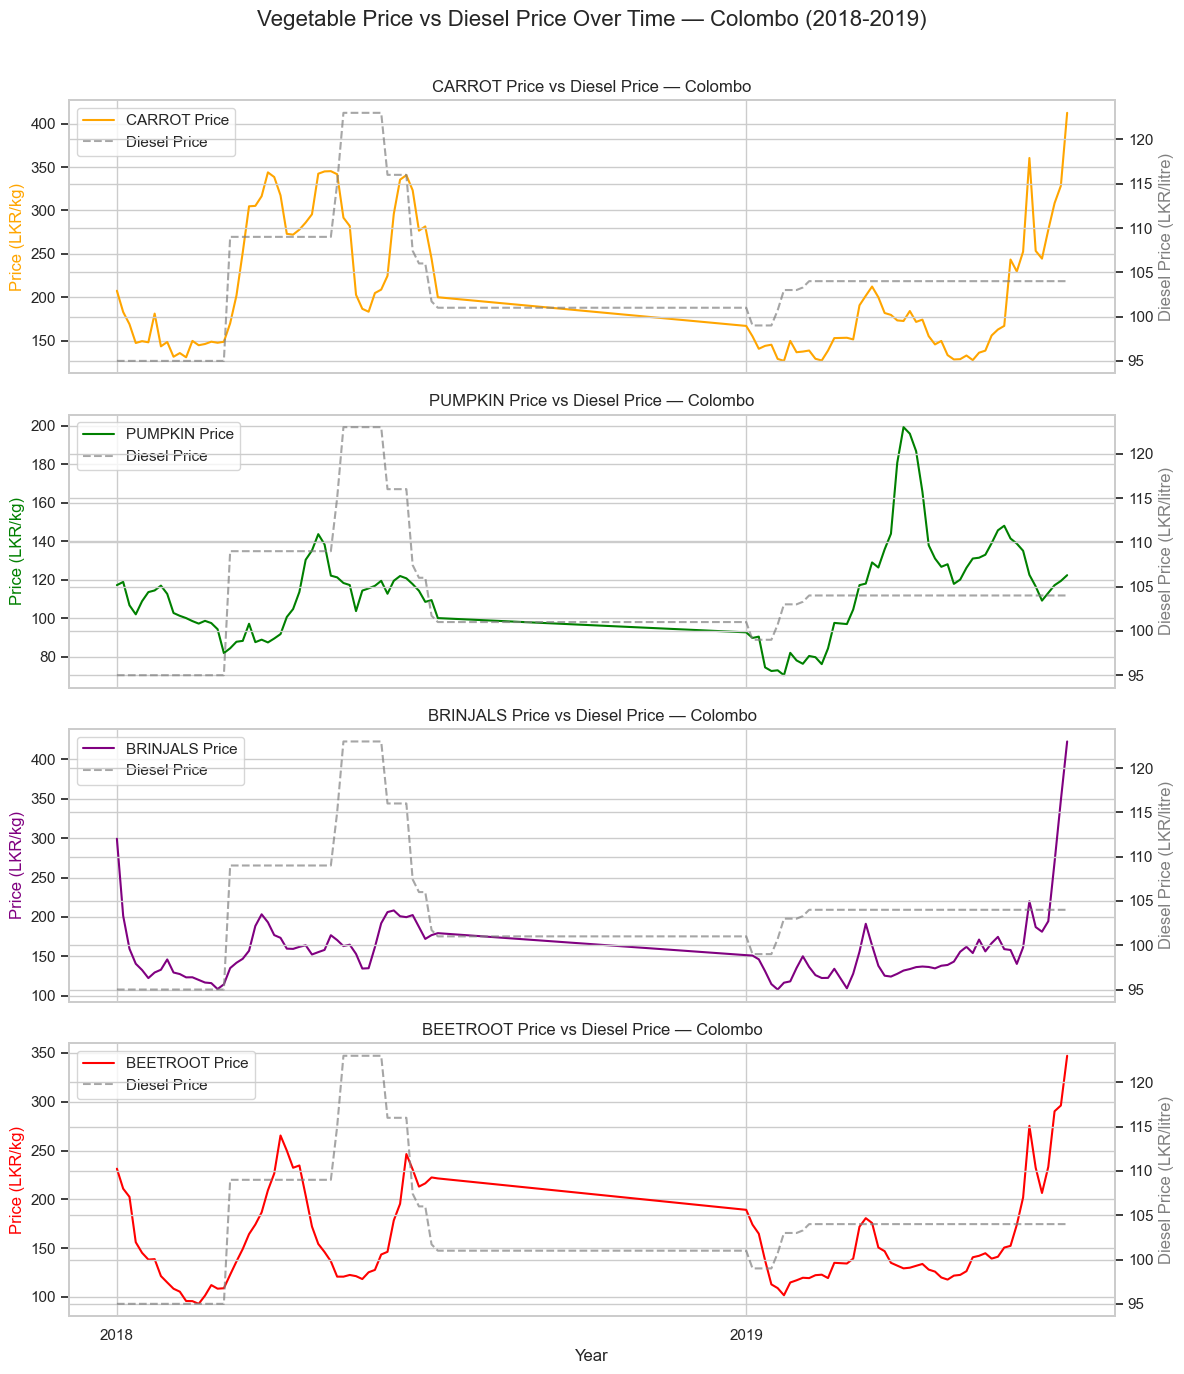

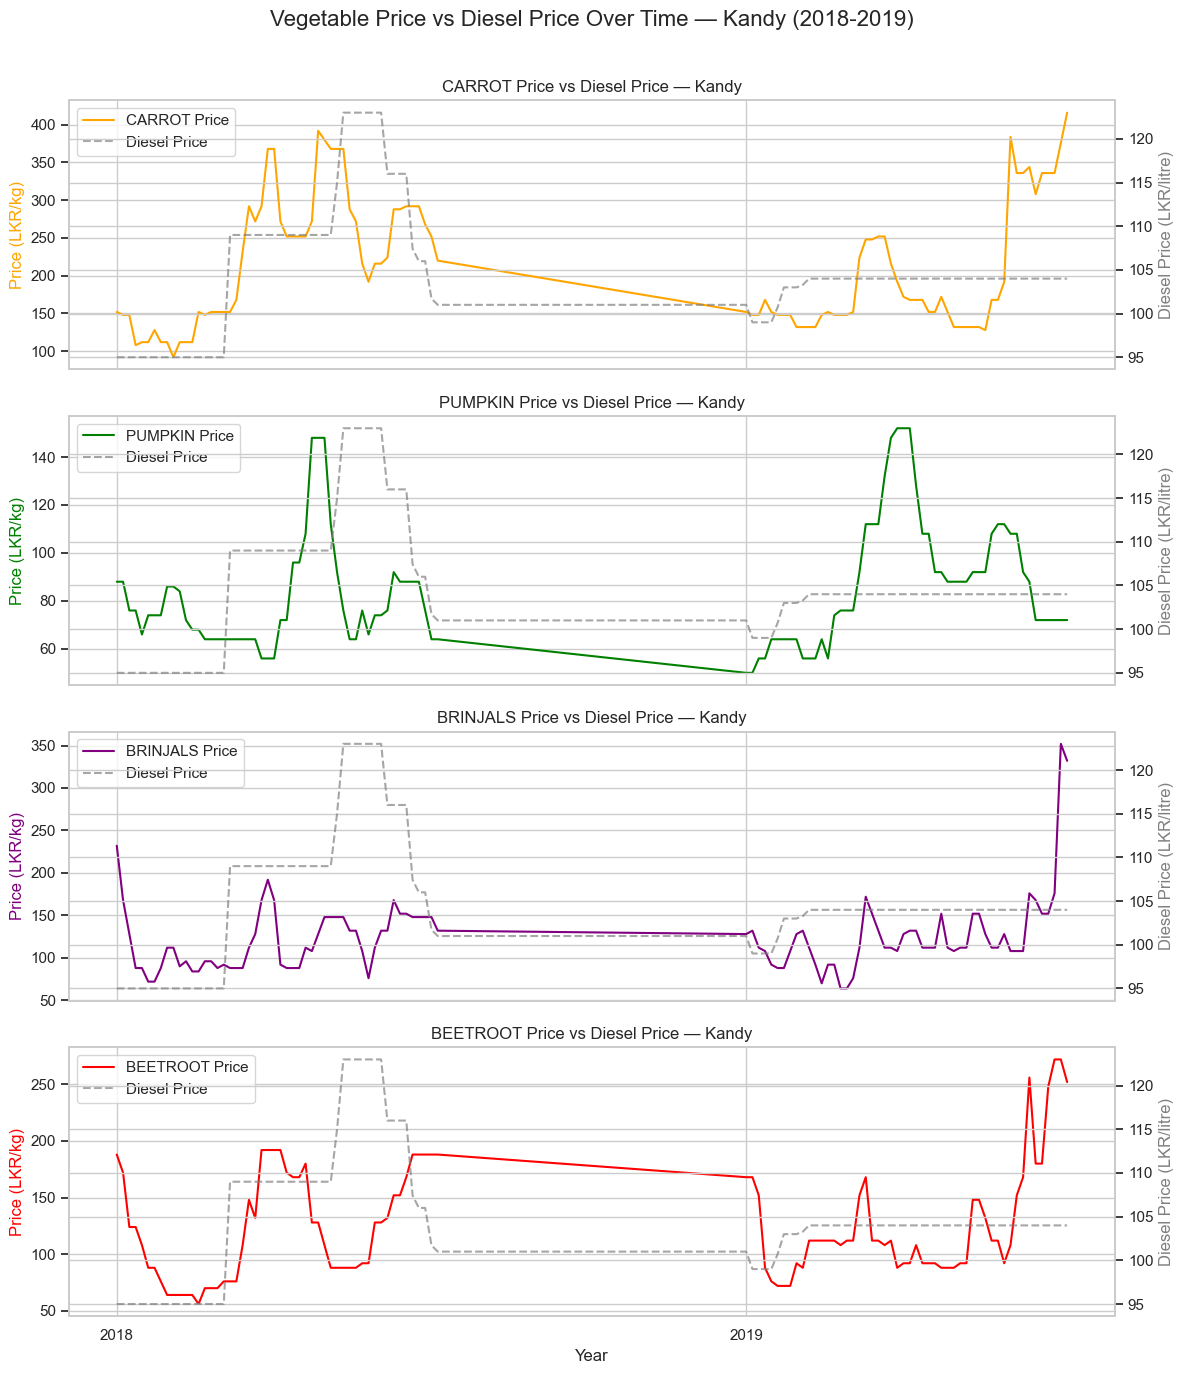

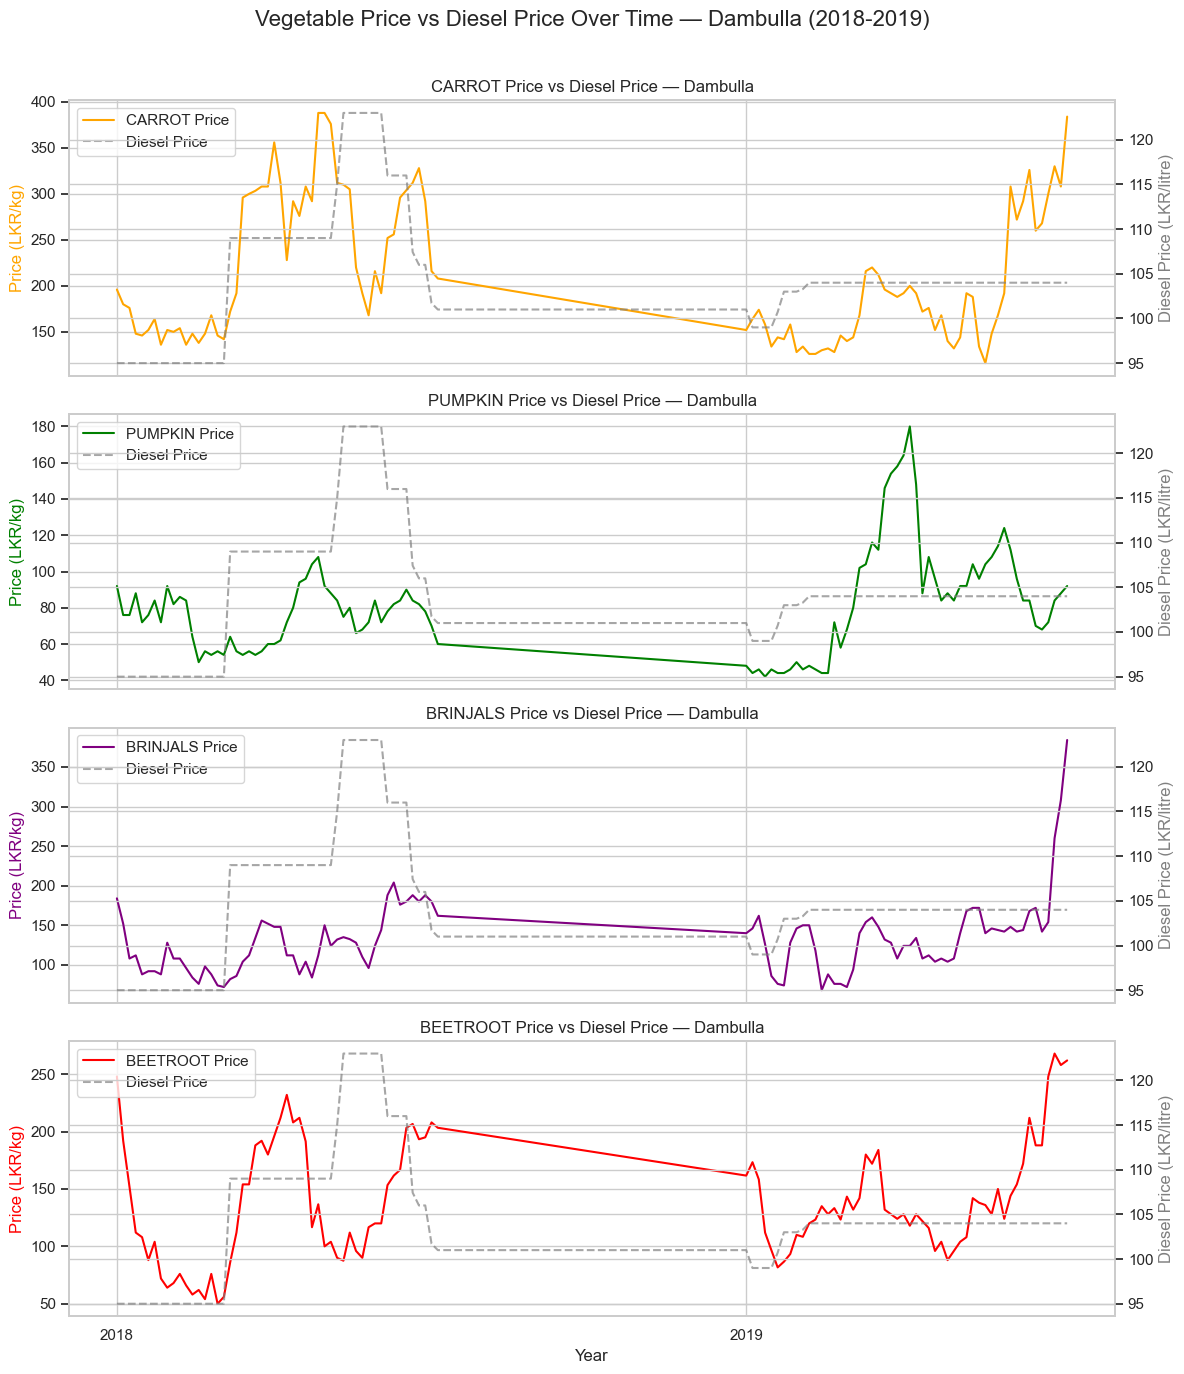

In [6]:
for loc, fname in zip(['Colombo', 'Kandy', 'Dambulla'], ['plot4_dual_axis_colombo_2018_2019.png', 'plot5_dual_axis_kandy_2018_2019.png', 'plot6_dual_axis_dambulla_2018_2019.png']):
    df_loc = df[(df['location'] == loc) & (df['vegetable_type'].isin(veg_list))].copy()
    df_loc['time_index'] = df_loc['year'] * 100 + df_loc['week_num']
    df_loc = df_loc.sort_values('time_index')
    df_loc = df_loc.dropna(subset=['price'])
    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
    for i, veg in enumerate(veg_list):
        ax = axes[i]
        data = df_loc[df_loc['vegetable_type'] == veg]
        l1 = ax.plot(data['time_index'], data['price'], color=veg_colors[veg], label=f'{veg} Price')
        ax.set_ylabel('Price (LKR/kg)', color=veg_colors[veg])
        ax2 = ax.twinx()
        l2 = ax2.plot(data['time_index'], data['lanka_auto_diesel_price'], color='grey', linestyle='--', alpha=0.7, label='Diesel Price')
        ax2.set_ylabel('Diesel Price (LKR/litre)', color='grey')
        ax.set_title(f'{veg} Price vs Diesel Price — {loc}')
        lines = l1 + l2
        labels = [l.get_label() for l in lines]
        ax.legend(lines, labels, loc='upper left')
        years = sorted(data['year'].unique())
        xticks = [y * 100 + 1 for y in years]
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(y) for y in years])
        if i < 3:
            ax.set_xlabel('')
        else:
            ax.set_xlabel('Year')
    plt.suptitle(f'Vegetable Price vs Diesel Price Over Time — {loc} (2018-2019)', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

## Summary: Pearson Correlation (Meegoda)
- For each vegetable, print the Pearson r and a one-line interpretation.

In [7]:
print('Pearson Correlation between Diesel Price and Vegetable Price (Meegoda, 2018-2019):\n')
for veg in veg_list:
    data = df_meegoda[df_meegoda['vegetable_type'] == veg]
    if len(data) > 1:
        r, p = pearsonr(data['lanka_auto_diesel_price'], data['price'])
        print(f'{veg}: r = {r:.2f} (p = {p:.3g})')
        if abs(r) < 0.2:
            interp = 'No or very weak linear relationship.'
        elif abs(r) < 0.5:
            interp = 'Moderate linear relationship.'
        else:
            interp = 'Strong linear relationship.'
        print(f'  Interpretation: {interp}')
    else:
        print(f'{veg}: Not enough data.')

Pearson Correlation between Diesel Price and Vegetable Price (Meegoda, 2018-2019):

CARROT: r = 0.45 (p = 2.73e-06)
  Interpretation: Moderate linear relationship.
PUMPKIN: r = -0.01 (p = 0.911)
  Interpretation: No or very weak linear relationship.
BRINJALS: r = 0.14 (p = 0.156)
  Interpretation: No or very weak linear relationship.
BEETROOT: r = 0.13 (p = 0.207)
  Interpretation: No or very weak linear relationship.


Mutual Information between Diesel Price and Vegetable Price (Meegoda, 2018-2019):

CARROT: MI = 0.3912
PUMPKIN: MI = 0.3557
BRINJALS: MI = 0.1960
BEETROOT: MI = 0.3653


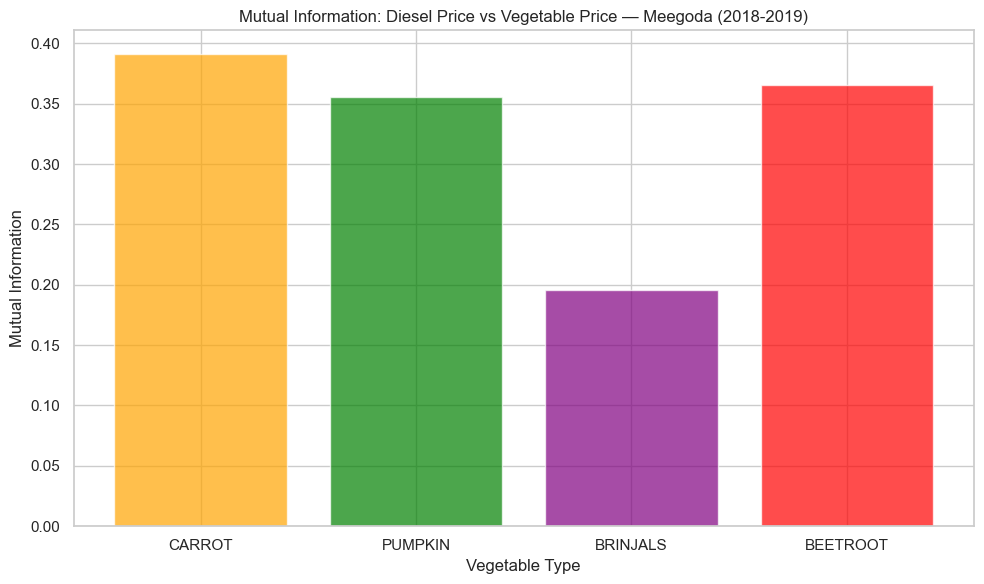

In [8]:
from sklearn.feature_selection import mutual_info_regression

# Calculate mutual information between diesel price and each vegetable price
mi_scores = {}

for veg in veg_list:
    data = df_meegoda[df_meegoda['vegetable_type'] == veg]
    if len(data) > 1:
        X = data['lanka_auto_diesel_price'].values.reshape(-1, 1)
        y = data['price'].values
        mi = mutual_info_regression(X, y, random_state=42)
        mi_scores[veg] = mi[0]
    else:
        mi_scores[veg] = 0

print('Mutual Information between Diesel Price and Vegetable Price (Meegoda, 2018-2019):\n')
for veg in veg_list:
    print(f'{veg}: MI = {mi_scores[veg]:.4f}')

# Visualize mutual information scores
plt.figure(figsize=(10, 6))
vegs = list(mi_scores.keys())
mi_vals = list(mi_scores.values())
colors = [veg_colors[v] for v in vegs]
plt.bar(vegs, mi_vals, color=colors, alpha=0.7)
plt.xlabel('Vegetable Type')
plt.ylabel('Mutual Information')
plt.title('Mutual Information: Diesel Price vs Vegetable Price — Meegoda (2018-2019)')
plt.tight_layout()
plt.savefig('plot7_mutual_information_meegoda_2018_2019.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
from scipy.stats import spearmanr

print('Spearman Correlation between Diesel Price and Vegetable Price (Meegoda, 2018-2019):\n')
for veg in veg_list:
    data = df_meegoda[df_meegoda['vegetable_type'] == veg]
    if len(data) > 1:
        r_s, p_s = spearmanr(data['lanka_auto_diesel_price'], data['price'])
        print(f'{veg}: Spearman r = {r_s:.2f} (p = {p_s:.3g})')
        if abs(r_s) < 0.2:
            interp = 'No or very weak monotonic relationship.'
        elif abs(r_s) < 0.5:
            interp = 'Moderate monotonic relationship.'
        else:
            interp = 'Strong monotonic relationship.'
        print(f'  Interpretation: {interp}')
    else:
        print(f'{veg}: Not enough data.')

Spearman Correlation between Diesel Price and Vegetable Price (Meegoda, 2018-2019):

CARROT: Spearman r = 0.61 (p = 8.95e-12)
  Interpretation: Strong monotonic relationship.
PUMPKIN: Spearman r = 0.07 (p = 0.465)
  Interpretation: No or very weak monotonic relationship.
BRINJALS: Spearman r = 0.33 (p = 0.000652)
  Interpretation: Moderate monotonic relationship.
BEETROOT: Spearman r = 0.31 (p = 0.00155)
  Interpretation: Moderate monotonic relationship.
